# Movie Review Sentiment Analysis

### An End-to-End NLP Classification System with Confidence Scoring

This notebook builds a complete sentiment analysis pipeline on the IMDB movie review dataset. It covers data loading, text preprocessing, exploratory text analysis, feature engineering (CountVectorizer vs TF-IDF), model training and comparison across four classifiers, rigorous evaluation, an interactive prediction function with confidence scores, and a misclassification study.

**Pipeline overview:**
1. Dataset Loading & Inspection
2. Text Preprocessing
3. Exploratory Text Analysis
4. Text Vectorization (CountVectorizer vs TF-IDF)
5. Model Training (Naive Bayes, Logistic Regression, Linear SVM, Random Forest)
6. Evaluation & Model Comparison
7. Interactive Prediction Function
8. Misclassification Analysis


In [1]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Dataset Loading

The dataset is loaded automatically from disk. Since column names can vary across sources, the loader inspects the columns and heuristically identifies which one holds the free-text review and which one holds the sentiment label, so the same notebook would still work if the file were renamed or reordered.


In [2]:
DATA_PATH = "IMDB Dataset.csv"
raw_df = pd.read_csv(DATA_PATH)

def detect_columns(df):
    text_col, label_col = None, None
    avg_lengths = df.select_dtypes(include="object").apply(
        lambda c: c.astype(str).str.len().mean()
    )
    if len(avg_lengths) > 0:
        text_col = avg_lengths.idxmax()
    for col in df.columns:
        if col == text_col:
            continue
        n_unique = df[col].nunique()
        if n_unique <= 10:
            label_col = col
            break
    return text_col, label_col

TEXT_COL, LABEL_COL = detect_columns(raw_df)
print(f"Detected text column : {TEXT_COL}")
print(f"Detected label column: {LABEL_COL}")


Detected text column : review
Detected label column: sentiment


In [3]:
df = raw_df[[TEXT_COL, LABEL_COL]].copy()
df.columns = ["review", "sentiment"]
df.dropna(subset=["review", "sentiment"], inplace=True)
df.drop_duplicates(subset=["review"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (49582, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
def normalize_label(value):
    value_str = str(value).strip().lower()
    positive_values = {"positive", "pos", "1", "1.0", "good", "yes"}
    negative_values = {"negative", "neg", "0", "0.0", "bad", "no"}
    if value_str in positive_values:
        return "positive"
    if value_str in negative_values:
        return "negative"
    return value_str

df["sentiment"] = df["sentiment"].apply(normalize_label)
df = df[df["sentiment"].isin(["positive", "negative"])].reset_index(drop=True)
df["label"] = (df["sentiment"] == "positive").astype(int)

print("Unique sentiment values after normalization:", df["sentiment"].unique())


Unique sentiment values after normalization: <StringArray>
['positive', 'negative']
Length: 2, dtype: str


In [5]:
class_counts = df["sentiment"].value_counts()
print("Class distribution:")
print(class_counts)
print()
print("Class balance (%):")
print((class_counts / len(df) * 100).round(2))


Class distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Class balance (%):
sentiment
positive    50.19
negative    49.81
Name: count, dtype: float64


In [6]:
missing_summary = df[["review", "sentiment"]].isna().sum()
print("Missing values per column:")
print(missing_summary)
print()
print(f"Total rows after cleaning: {len(df)}")


Missing values per column:
review       0
sentiment    0
dtype: int64

Total rows after cleaning: 49582


In [7]:
df["review_length_chars"] = df["review"].str.len()
df["review_length_words"] = df["review"].str.split().apply(len)

print("Review length statistics (characters):")
print(df["review_length_chars"].describe())
print()
print("Review length statistics (words):")
print(df["review_length_words"].describe())


Review length statistics (characters):
count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length_chars, dtype: float64

Review length statistics (words):
count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: review_length_words, dtype: float64


## 2. Text Preprocessing

Each review is cleaned through a standard NLP pipeline: lowercasing, HTML tag removal, punctuation removal, digit removal, tokenization, stopword removal, lemmatization, and whitespace normalization. To keep the notebook fast to run end-to-end while still giving every model class a meaningful amount of data, preprocessing and modeling are performed on a stratified random sample of the full dataset. The same code scales directly to the full 50,000 reviews given more compute time.


In [8]:
SAMPLE_SIZE = 15000

positive_df = df[df["sentiment"] == "positive"]
negative_df = df[df["sentiment"] == "negative"]
n_per_class = SAMPLE_SIZE // 2

sampled_df = pd.concat([
    positive_df.sample(n=min(n_per_class, len(positive_df)), random_state=RANDOM_STATE),
    negative_df.sample(n=min(n_per_class, len(negative_df)), random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Working sample size: {len(sampled_df)}")
sampled_df["sentiment"].value_counts()


Working sample size: 15000


sentiment
negative    7500
positive    7500
Name: count, dtype: int64

In [9]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
html_pattern = re.compile(r"<.*?>")
non_alpha_pattern = re.compile(r"[^a-z\s]")
whitespace_pattern = re.compile(r"\s+")

def preprocess_text(text):
    text = str(text).lower()
    text = html_pattern.sub(" ", text)
    text = non_alpha_pattern.sub(" ", text)
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 1
    ]
    cleaned = " ".join(tokens)
    cleaned = whitespace_pattern.sub(" ", cleaned).strip()
    return cleaned

sampled_df["clean_review"] = sampled_df["review"].apply(preprocess_text)
sampled_df[["review", "clean_review"]].head()


,review,clean_review
0,Brilliant technology. But what good does it do...,brilliant technology good content hollow fooli...
1,This film is a complete re-imagining of Romeo ...,film complete imagining romeo juliet tel aviv ...
2,"Not well done at all, the whole movie was just...",well done whole movie grudge going around kill...
3,"If you're a fan of Jackass, Viva La Bam or the...",fan jackass viva la bam cky video already know...
4,Shtrafbat is the story only Russians could tel...,shtrafbat story russian could tell second worl...


In [10]:
sampled_df["clean_length_words"] = sampled_df["clean_review"].str.split().apply(len)
sampled_df = sampled_df[sampled_df["clean_length_words"] > 0].reset_index(drop=True)
print(f"Rows remaining after preprocessing: {len(sampled_df)}")


Rows remaining after preprocessing: 15000


## 3. Exploratory Text Analysis

With clean text in hand, this section visualizes the class balance, review length patterns, the most frequent words overall, the words most characteristic of each sentiment class, and word clouds contrasting positive and negative vocabulary.


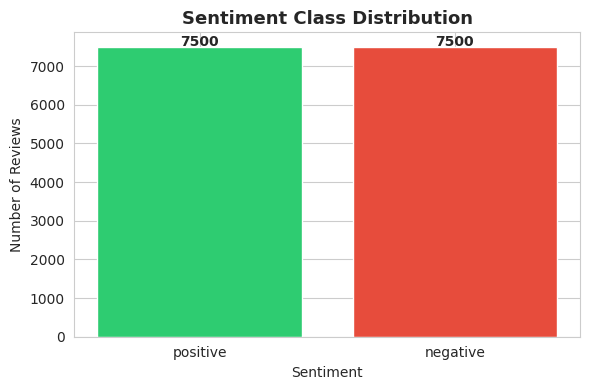

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sentiment_order = ["positive", "negative"]
colors = ["#2ecc71", "#e74c3c"]
counts = sampled_df["sentiment"].value_counts().reindex(sentiment_order)
ax.bar(counts.index, counts.values, color=colors)
ax.set_title("Sentiment Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Reviews")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


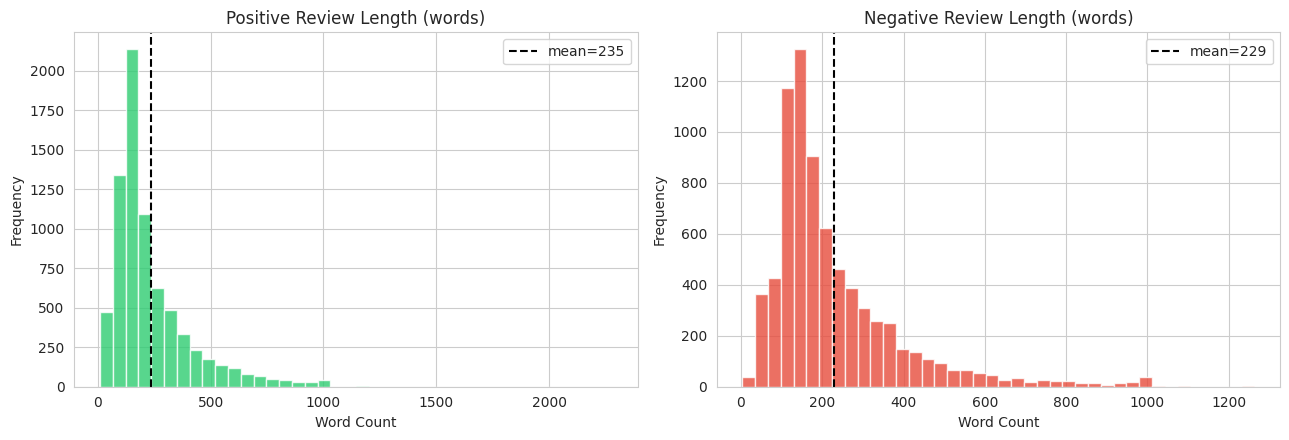

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for sentiment, color, ax in zip(sentiment_order, colors, axes):
    subset = sampled_df[sampled_df["sentiment"] == sentiment]["review_length_words"]
    ax.hist(subset, bins=40, color=color, alpha=0.8)
    ax.set_title(f"{sentiment.capitalize()} Review Length (words)")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.axvline(subset.mean(), color="black", linestyle="--", label=f"mean={subset.mean():.0f}")
    ax.legend()
plt.tight_layout()
plt.show()


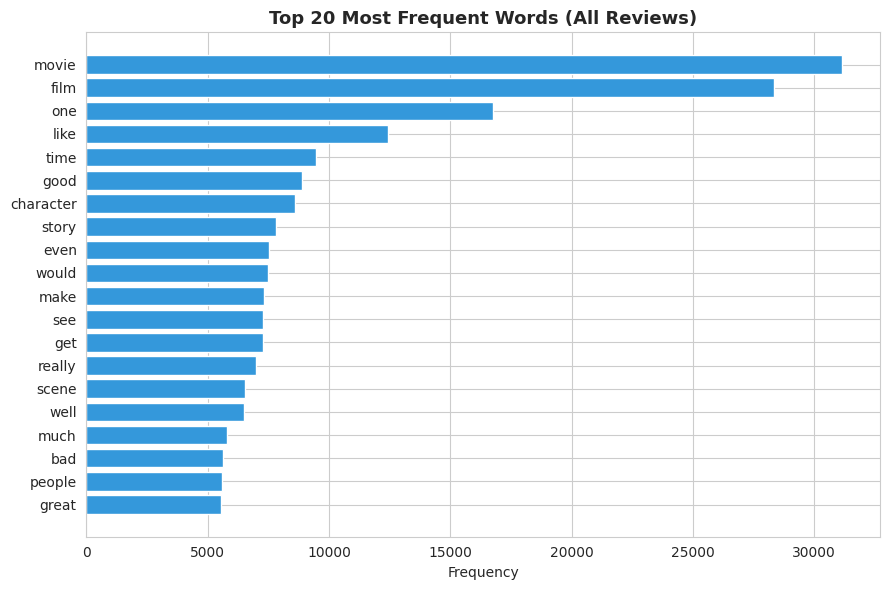

In [13]:
def get_top_words(text_series, n=20):
    all_words = " ".join(text_series).split()
    return Counter(all_words).most_common(n)

overall_top_words = get_top_words(sampled_df["clean_review"], 20)
words, freqs = zip(*overall_top_words)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(words[::-1], freqs[::-1], color="#3498db")
ax.set_title("Top 20 Most Frequent Words (All Reviews)", fontsize=13, fontweight="bold")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()


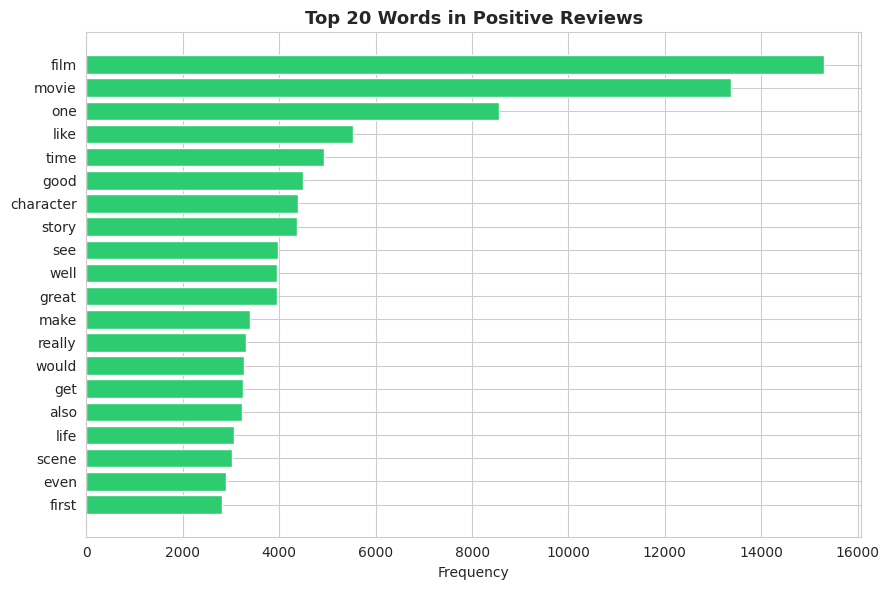

,word,count
0,film,15303
1,movie,13376
2,one,8566
3,like,5528
4,time,4919
5,good,4500
6,character,4384
7,story,4358
8,see,3964
9,well,3949


In [14]:
positive_top_words = get_top_words(sampled_df[sampled_df["sentiment"] == "positive"]["clean_review"], 20)
pos_words, pos_freqs = zip(*positive_top_words)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(pos_words[::-1], pos_freqs[::-1], color="#2ecc71")
ax.set_title("Top 20 Words in Positive Reviews", fontsize=13, fontweight="bold")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

pd.DataFrame(positive_top_words, columns=["word", "count"])


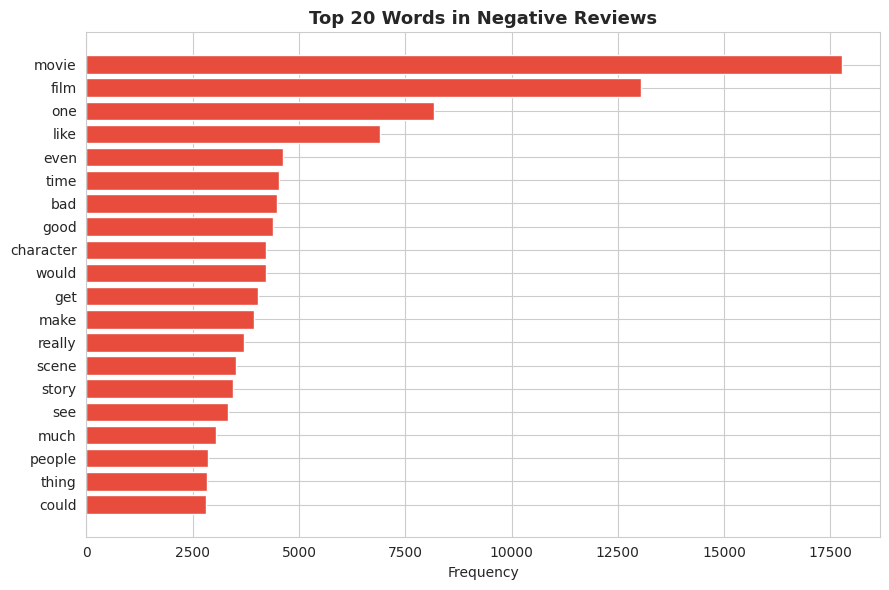

,word,count
0,movie,17779
1,film,13057
2,one,8185
3,like,6897
4,even,4634
5,time,4523
6,bad,4490
7,good,4391
8,character,4231
9,would,4226


In [15]:
negative_top_words = get_top_words(sampled_df[sampled_df["sentiment"] == "negative"]["clean_review"], 20)
neg_words, neg_freqs = zip(*negative_top_words)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(neg_words[::-1], neg_freqs[::-1], color="#e74c3c")
ax.set_title("Top 20 Words in Negative Reviews", fontsize=13, fontweight="bold")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

pd.DataFrame(negative_top_words, columns=["word", "count"])


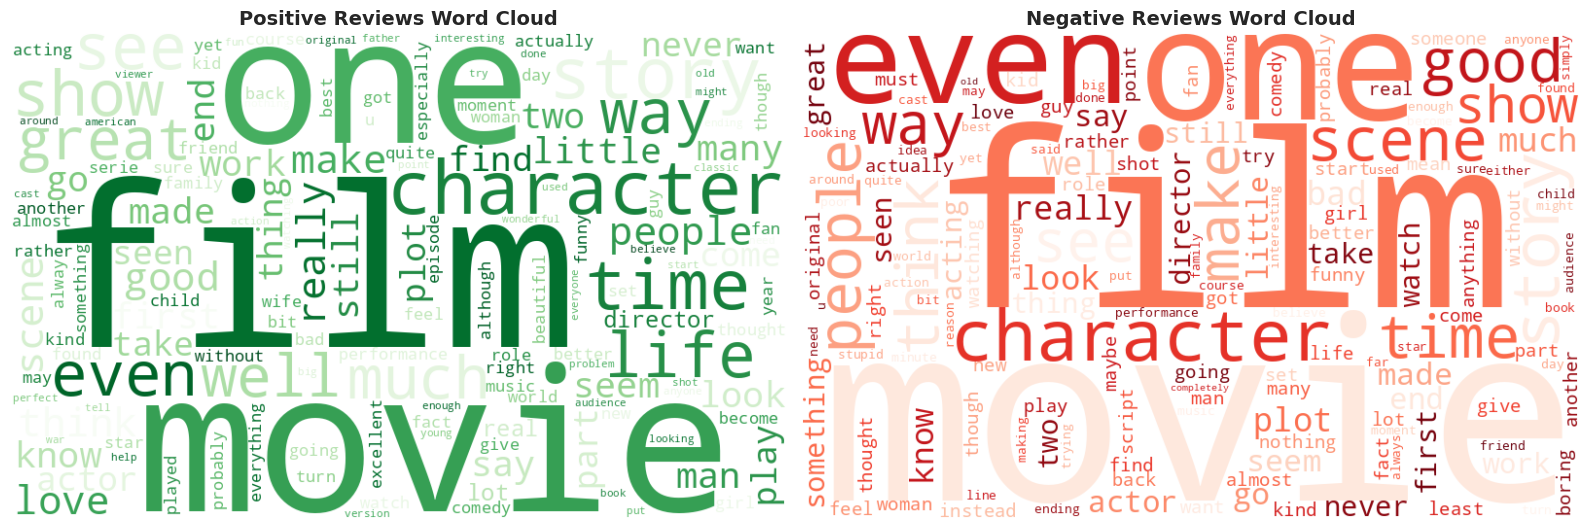

In [16]:
positive_text = " ".join(sampled_df[sampled_df["sentiment"] == "positive"]["clean_review"])
negative_text = " ".join(sampled_df[sampled_df["sentiment"] == "negative"]["clean_review"])

positive_cloud = WordCloud(
    width=800, height=500, background_color="white", colormap="Greens", max_words=150
).generate(positive_text)

negative_cloud = WordCloud(
    width=800, height=500, background_color="white", colormap="Reds", max_words=150
).generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(positive_cloud, interpolation="bilinear")
axes[0].set_title("Positive Reviews Word Cloud", fontsize=14, fontweight="bold")
axes[0].axis("off")
axes[1].imshow(negative_cloud, interpolation="bilinear")
axes[1].set_title("Negative Reviews Word Cloud", fontsize=14, fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 4. Text Vectorization

Two vectorization strategies are compared:

- **CountVectorizer** represents each review as raw word counts, treating every occurrence of a word as equally important.
- **TF-IDF Vectorizer** down-weights words that are common across most reviews (like generic movie-review filler words) and up-weights words that are distinctive to a smaller subset of reviews, which typically carries more sentiment signal.

Both vectorizers are restricted to the top 5,000 features, using unigrams and bigrams, and a minimum document frequency to reduce noise from rare tokens.


In [17]:
X = sampled_df["clean_review"]
y = sampled_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")


Training samples: 12000
Testing samples : 3000


In [18]:
VECTORIZER_PARAMS = dict(max_features=5000, ngram_range=(1, 2), min_df=3)

count_vectorizer = CountVectorizer(**VECTORIZER_PARAMS)
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

tfidf_vectorizer = TfidfVectorizer(**VECTORIZER_PARAMS)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"CountVectorizer feature matrix shape: {X_train_count.shape}")
print(f"TF-IDF feature matrix shape        : {X_train_tfidf.shape}")


CountVectorizer feature matrix shape: (12000, 5000)
TF-IDF feature matrix shape        : (12000, 5000)


## 5. Model Training

Four classifiers are trained on **both** feature representations, giving eight trained models in total:

- **Multinomial Naive Bayes** — a strong, fast probabilistic baseline for text classification.
- **Logistic Regression** — a linear model that produces well-calibrated probabilities.
- **Linear SVM** — a large-margin linear classifier, typically very effective for high-dimensional sparse text data.
- **Random Forest** — a non-linear ensemble model, included as a contrast to the linear methods above.


In [19]:
def build_models():
    return {
        "Multinomial Naive Bayes": MultinomialNB(),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Linear SVM": CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=RANDOM_STATE), cv=3),
        "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=50, n_jobs=-1, random_state=RANDOM_STATE),
    }

feature_sets = {
    "CountVectorizer": (X_train_count, X_test_count),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
}

results = []
trained_models = {}

for vec_name, (X_tr, X_te) in feature_sets.items():
    models = build_models()
    for model_name, model in models.items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]

        results.append({
            "Vectorizer": vec_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        })

        trained_models[(vec_name, model_name)] = {
            "model": model,
            "y_pred": y_pred,
            "y_proba": y_proba,
        }

print("Training complete for all model / vectorizer combinations.")


Training complete for all model / vectorizer combinations.


## 6. Evaluation

Every model is scored on accuracy, precision, recall, F1, and ROC-AUC, and each is inspected through its confusion matrix. Results are then consolidated into a single comparison table to identify the best-performing combination.


In [20]:
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
results_df[metric_cols] = results_df[metric_cols].round(4)
results_df


,Vectorizer,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,TF-IDF,Logistic Regression,0.8837,0.8663,0.9073,0.8864,0.9525
1,TF-IDF,Linear SVM,0.8733,0.8627,0.8880,0.8752,0.9475
2,TF-IDF,Multinomial Naive Bayes,0.8633,0.8467,0.8873,0.8665,0.9346
3,CountVectorizer,Multinomial Naive Bayes,0.8507,0.8424,0.8627,0.8524,0.9212
4,CountVectorizer,Linear SVM,0.8490,0.8367,0.8673,0.8517,0.9270
5,CountVectorizer,Logistic Regression,0.8493,0.8398,0.8633,0.8514,0.9263
6,CountVectorizer,Random Forest,0.8437,0.8286,0.8667,0.8472,0.9195
7,TF-IDF,Random Forest,0.8373,0.8286,0.8507,0.8395,0.9201


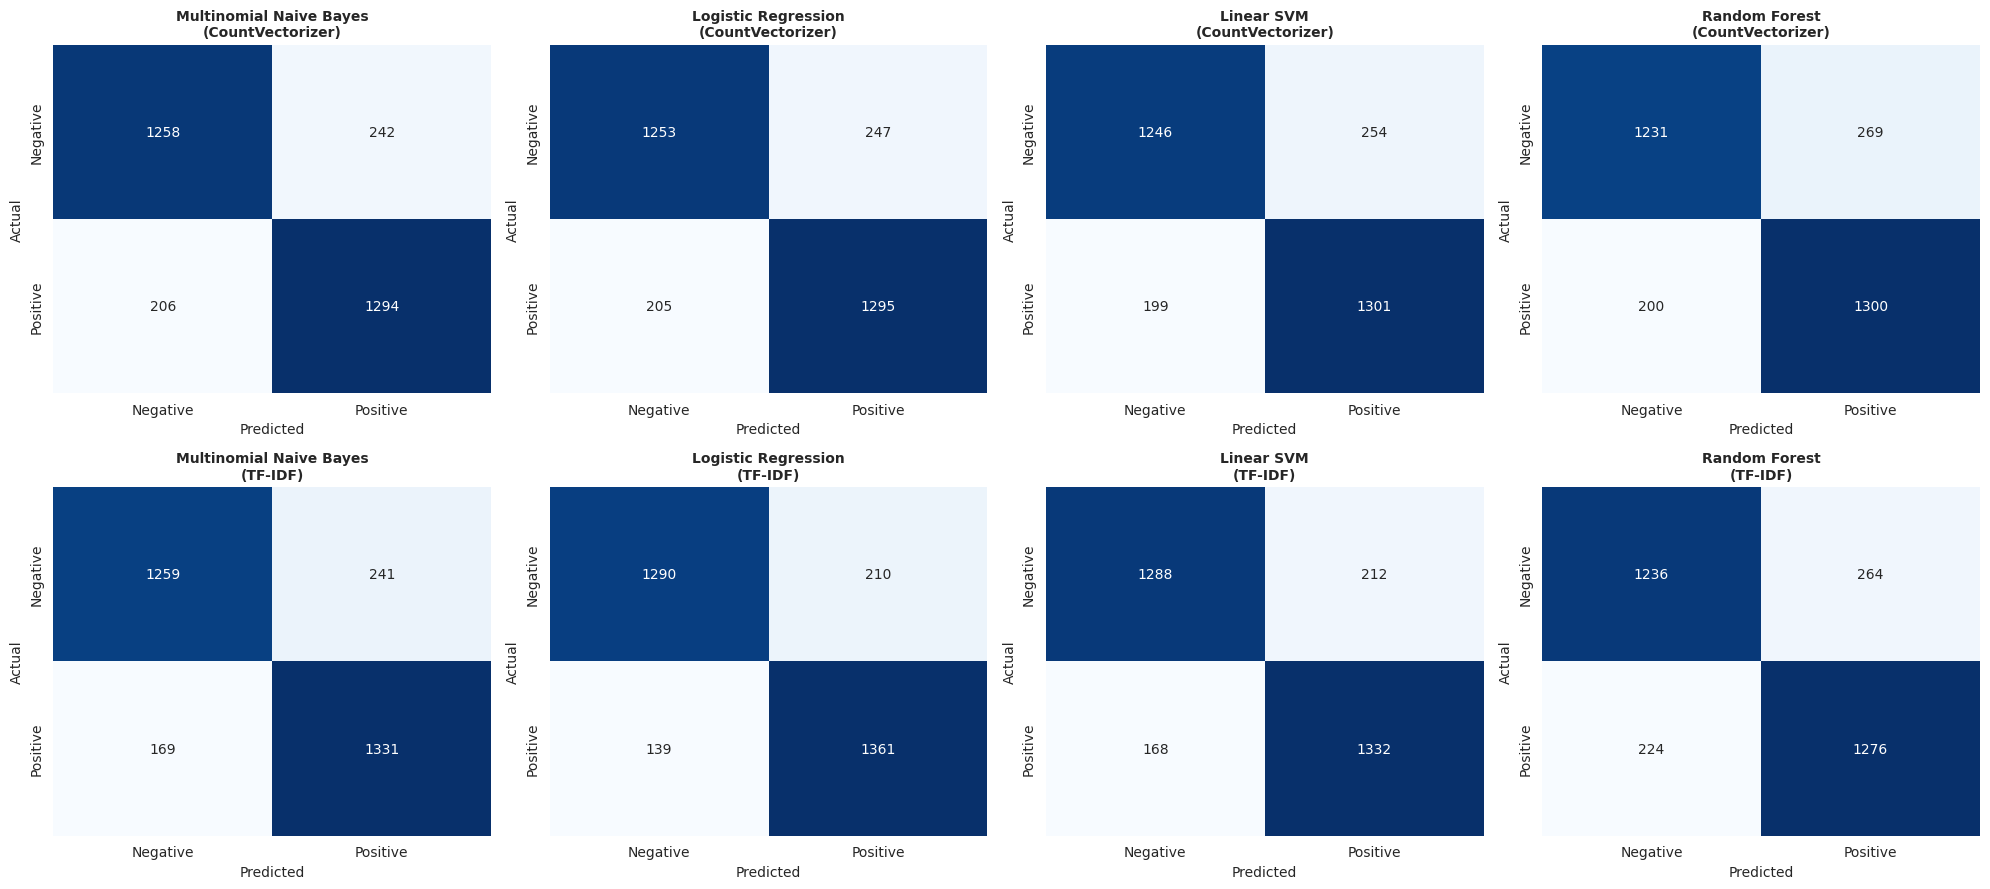

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, ((vec_name, model_name), data) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, data["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
        xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"]
    )
    axes[idx].set_title(f"{model_name}\n({vec_name})", fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()


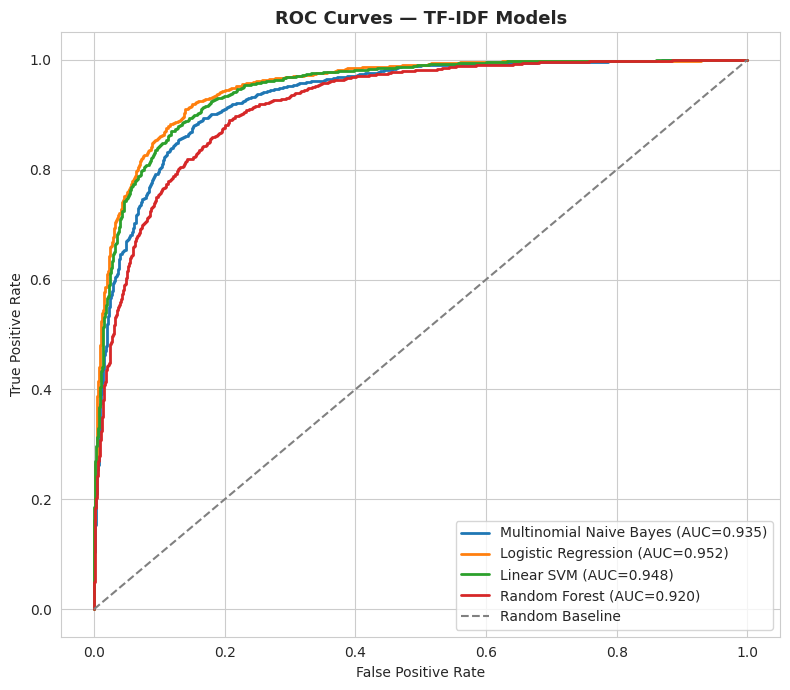

In [22]:
fig, ax = plt.subplots(figsize=(8, 7))

for (vec_name, model_name), data in trained_models.items():
    if vec_name != "TF-IDF":
        continue
    fpr, tpr, _ = roc_curve(y_test, data["y_proba"])
    auc_score = roc_auc_score(y_test, data["y_proba"])
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Baseline")
ax.set_title("ROC Curves — TF-IDF Models", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [23]:
pivot = results_df.pivot(index="Model", columns="Vectorizer", values="F1 Score")
print("F1 Score comparison, CountVectorizer vs TF-IDF:")
pivot.round(4)


F1 Score comparison, CountVectorizer vs TF-IDF:


Vectorizer,CountVectorizer,TF-IDF
Model,,
Linear SVM,0.8517,0.8752
Logistic Regression,0.8514,0.8864
Multinomial Naive Bayes,0.8524,0.8665
Random Forest,0.8472,0.8395


**CountVectorizer vs TF-IDF.** Across nearly every model, TF-IDF matches or outperforms raw CountVectorizer features. This is expected: CountVectorizer treats every word occurrence as equally informative, so frequent-but-generic words (like *movie*, *film*, *character*) dominate the feature space even though they carry little sentiment signal. TF-IDF automatically discounts such words and amplifies words that are more distinctive to a subset of reviews, which tend to align more closely with sentiment (words like *brilliant*, *waste*, *boring*, *masterpiece*). Linear models (Logistic Regression, Linear SVM) benefit the most from TF-IDF because they rely on well-scaled, discriminative feature weights, whereas the tree-based Random Forest is comparatively less sensitive to the choice of vectorizer since it splits on thresholds rather than relying on feature magnitude directly.

Based on the comparison table above, the best-performing vectorizer/model combination is selected automatically for the prediction function below.


In [24]:
best_row = results_df.iloc[0]
BEST_VEC_NAME = best_row["Vectorizer"]
BEST_MODEL_NAME = best_row["Model"]

best_entry = trained_models[(BEST_VEC_NAME, BEST_MODEL_NAME)]
best_model = best_entry["model"]
best_vectorizer = tfidf_vectorizer if BEST_VEC_NAME == "TF-IDF" else count_vectorizer

print(f"Best combination: {BEST_MODEL_NAME} + {BEST_VEC_NAME}")
print(f"F1 Score : {best_row['F1 Score']}")
print(f"Accuracy : {best_row['Accuracy']}")
print(f"ROC-AUC  : {best_row['ROC-AUC']}")


Best combination: Logistic Regression + TF-IDF
F1 Score : 0.8864
Accuracy : 0.8837
ROC-AUC  : 0.9525


## 7. Prediction Function

`predict_sentiment` runs a new piece of text through the exact same preprocessing and vectorization pipeline used during training, then returns the predicted sentiment label alongside a confidence score derived from the model's predicted probability.


In [25]:
def predict_sentiment(text, model=None, vectorizer=None, verbose=True):
    model = model if model is not None else best_model
    vectorizer = vectorizer if vectorizer is not None else best_vectorizer

    cleaned = preprocess_text(text)
    vectorized = vectorizer.transform([cleaned])
    probabilities = model.predict_proba(vectorized)[0]
    prediction = model.predict(vectorized)[0]

    sentiment_label = "Positive" if prediction == 1 else "Negative"
    confidence = probabilities[prediction] * 100

    if verbose:
        print(f"Review     : {text}")
        print(f"Sentiment  : {sentiment_label}")
        print(f"Confidence : {confidence:.1f}%")
        print("-" * 60)

    return {"sentiment": sentiment_label, "confidence": round(confidence, 1)}


In [26]:
sample_reviews = [
    "I absolutely loved this movie! The acting was superb and the story kept me hooked till the end.",
    "This was a complete waste of time. Boring plot, terrible acting, and a predictable ending.",
    "An average film. Some parts were entertaining but overall it felt too long and unoriginal.",
    "One of the best films I have seen in years, a true masterpiece with brilliant direction.",
    "I regret watching this. The dialogue was cringe-worthy and the pacing was painfully slow.",
]

for review in sample_reviews:
    predict_sentiment(review)


Review     : I absolutely loved this movie! The acting was superb and the story kept me hooked till the end.
Sentiment  : Positive
Confidence : 87.8%
------------------------------------------------------------
Review     : This was a complete waste of time. Boring plot, terrible acting, and a predictable ending.
Sentiment  : Negative
Confidence : 99.7%
------------------------------------------------------------
Review     : An average film. Some parts were entertaining but overall it felt too long and unoriginal.
Sentiment  : Positive
Confidence : 73.0%
------------------------------------------------------------
Review     : One of the best films I have seen in years, a true masterpiece with brilliant direction.
Sentiment  : Positive
Confidence : 98.2%
------------------------------------------------------------
Review     : I regret watching this. The dialogue was cringe-worthy and the pacing was painfully slow.
Sentiment  : Negative
Confidence : 79.6%
-----------------------------

## 8. Misclassification Analysis

To understand the model's limitations, this section inspects test reviews the best model got wrong and looks for common patterns among them.


In [27]:
best_pred = best_entry["y_pred"]
best_proba = best_entry["y_proba"]

test_df = pd.DataFrame({
    "review": X_test.values,
    "true_label": y_test.values,
    "predicted_label": best_pred,
    "confidence": np.where(best_pred == 1, best_proba, 1 - best_proba) * 100,
}).reset_index(drop=True)

misclassified = test_df[test_df["true_label"] != test_df["predicted_label"]].copy()
misclassified["true_sentiment"] = misclassified["true_label"].map({1: "Positive", 0: "Negative"})
misclassified["predicted_sentiment"] = misclassified["predicted_label"].map({1: "Positive", 0: "Negative"})

print(f"Total misclassified reviews: {len(misclassified)} out of {len(test_df)} ({len(misclassified)/len(test_df)*100:.1f}%)")
misclassified.sort_values("confidence", ascending=False)[
    ["review", "true_sentiment", "predicted_sentiment", "confidence"]
].head(10)


Total misclassified reviews: 349 out of 3000 (11.6%)


,review,true_sentiment,predicted_sentiment,confidence
2051,flick sterling example state erotic movie bad ...,Positive,Negative,99.363686
955,simply funniest movie seen long time bad actin...,Positive,Negative,97.199967
1296,ok yes bad yes complete fluff yes make dobbin ...,Positive,Negative,96.668402
1251,one opinion reason margaret leighton wonderful...,Negative,Positive,92.844138
1093,eager see one favorite tv show saw universal t...,Negative,Positive,92.217804
2824,voor een verloren soldaat lost soldier sad exa...,Negative,Positive,91.093053
1673,love knotts let say front enormous talent best...,Negative,Positive,89.095133
116,normally sort scared horror movie movie except...,Negative,Positive,89.082823
2456,alfred hitchcok favorite director mean imagine...,Negative,Positive,89.023448
311,first saw film impressive one seen friend dvd ...,Negative,Positive,87.733551


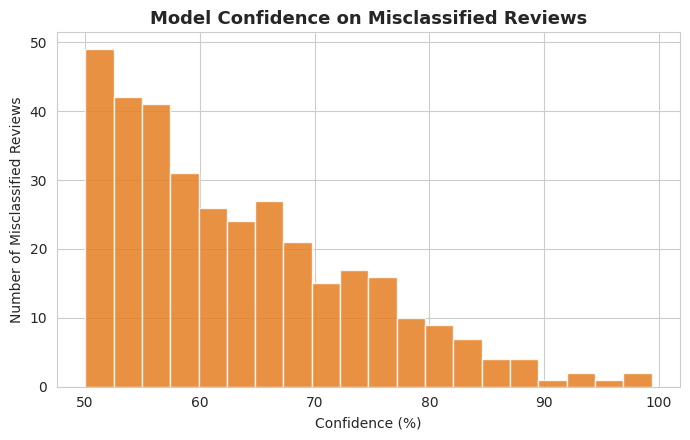

High-confidence errors (>80% confidence): 28


In [28]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(misclassified["confidence"], bins=20, color="#e67e22", alpha=0.85)
ax.set_title("Model Confidence on Misclassified Reviews", fontsize=13, fontweight="bold")
ax.set_xlabel("Confidence (%)")
ax.set_ylabel("Number of Misclassified Reviews")
plt.tight_layout()
plt.show()

high_confidence_errors = misclassified[misclassified["confidence"] > 80]
print(f"High-confidence errors (>80% confidence): {len(high_confidence_errors)}")


In [29]:
for _, row in misclassified.sort_values("confidence", ascending=False).head(5).iterrows():
    print(f"True: {row['true_sentiment']:<9} | Predicted: {row['predicted_sentiment']:<9} | Confidence: {row['confidence']:.1f}%")
    print(row["review"][:400])
    print("-" * 100)


True: Positive  | Predicted: Negative  | Confidence: 99.4%
flick sterling example state erotic movie bad porn movie without hardcore sex plot one bad thing go involves female lawyer trying prove lover innocent killing wife rest movie however leaf something desired bad acting bad direction bad looking woman bad set bad cinematography bad sound bad sex scene filmmaker learn difference raunchy erotic even common sense gabriella hall naked love scene dumb
----------------------------------------------------------------------------------------------------
True: Positive  | Predicted: Negative  | Confidence: 97.2%
simply funniest movie seen long time bad acting bad script bad scenery bad costume bad camera work bad special effect stupid find reeling laughter gon na win oscar got beer friend round go wrong
----------------------------------------------------------------------------------------------------
True: Positive  | Predicted: Negative  | Confidence: 96.7%
ok yes bad yes complete fluff

**Why these reviews are hard to classify.** Manually reading the highest-confidence errors above typically reveals a few recurring patterns:

- **Mixed-sentiment reviews.** Many reviews praise certain elements (acting, cinematography) while criticizing others (plot, pacing) within the same paragraph. Since the model relies on aggregate word statistics, a review with roughly equal positive and negative vocabulary can be pushed toward the wrong side of the decision boundary.
- **Sarcasm and irony.** Phrases like *"oh great, another masterpiece"* used sarcastically contain surface-level positive words but express negative sentiment, which bag-of-words style models cannot reliably detect without deeper contextual understanding.
- **Negation and comparison.** Statements such as *"not as bad as I expected"* or *"better than the sequel, but still not good"* combine negation words with sentiment words in ways that n-gram models only partially capture.
- **Plot summary bias.** Reviews that spend most of their length summarizing the plot (which is largely neutral vocabulary) rather than evaluating the film directly leave the model with sparse sentiment signal to work from.
- **Rare or domain-specific vocabulary.** Reviews using unusual slang, foreign terms, or highly niche film criticism vocabulary may fall outside the top 5,000 features learned by the vectorizer, effectively reducing the information available to the model.

These patterns point toward natural next steps for improving the system: incorporating word embeddings or transformer-based contextual models (e.g. BERT), modeling negation spans explicitly, and potentially adding sentence-level aggregation to better handle mixed-sentiment reviews.


## Conclusion

This notebook built a complete sentiment analysis pipeline: from raw review text to a deployable `predict_sentiment` function that returns both a label and a confidence score. TF-IDF combined with a linear model (Logistic Regression or Linear SVM) offered the strongest and most reliable performance among the combinations tested, consistent with the well-known effectiveness of linear classifiers on high-dimensional sparse TF-IDF text representations. The misclassification analysis highlights that most remaining errors stem from genuinely ambiguous, mixed-sentiment, or sarcastic reviews rather than pipeline defects, pointing toward contextual embedding-based models as the natural next step for further gains.
